In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import seaborn as sns

# ===================================================================
# 모델 및 파라미터 정의 (v5)
# ===================================================================

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


# --- 물리 모델 파라미터 (v5) ---
# ## 기본 파라미터
w1_base, w2_base, w3_base, b_base = 1.0, 0.8, 0.5, 40.0
# ## 레시피 교호작용 파라미터
w12_base = 0.02 # s1과 s2의 교호작용 강도

# ## 부자재 경시성 파라미터 (tanh 기반)
beta = 0.8       # 효율 감소 최대치 (0~1 사이)
beta_k = 0.1     # 효율 감소 곡선의 가파름
gamma = 3.0      # 불확실성 최대치
gamma_k = 0.1    # 불확실성 증가 곡선의 가파름

# ## 장비 경시성 파라미터
delta_w1 = 0.001   # w1 파라미터의 노후화 민감도
delta_w12 = 0.0001 # w12 교호작용 파라미터의 노후화 민감도
delta_b = 0.02     # b 파라미터의 노후화 민감도

# --- Task 품질 사양 (예시) ---
min_A_spec = 40.0
max_A_spec = 60.0
target_A_spec = (min_A_spec + max_A_spec) / 2 # 50.0

# --- 룰 기반 에이전트 파라미터 ---
U_max_consumable = 20
s2_default = 5.0 # 교호작용 효과를 보기 위해 s2 기본값 상향
s3_default = 5.0

In [42]:
# ## 2. A공정 복합 물리 모델 구현
#
# 효율 감소와 불확실성 증가를 포함한 물리 모델을 구현합니다.
def calculate_qa_model_v5(s1, s2, s3, u, m_age):
    """
    장비(m_age)/부자재(u) 이중 경시성, 레시피 비선형 교호작용,
    tanh 기반 부자재 영향을 모두 반영한 최종 물리 모델
    """
    # 1. 장비 경시성(m_age)에 따른 파라미터 변화
    w1 = w1_base * (1 - delta_w1 * m_age)
    w12 = w12_base * (1 - delta_w12 * m_age)
    b = b_base - delta_b * m_age
    
    # 2. 기본 품질 g(s) 계산 (비선형 교호작용 포함)
    linear_part = w1 * s1 + w2_base * s2 + w3_base * s3 + b
    nonlinear_interaction = w12 * s1 * s2
    g_s = linear_part + nonlinear_interaction
    
    # 3. 부자재 경시성(u)에 따른 효율 및 노이즈 계산 (tanh 기반)
    effectiveness = 1 - beta * np.tanh(beta_k * u)
    std_dev_noise = gamma * np.tanh(gamma_k * u)
    
    # 4. 최종 품질 계산
    mean_qa = g_s * effectiveness
    realized_qa = np.random.normal(mean_qa, std_dev_noise)
    
    return realized_qa, mean_qa, std_dev_noise
# 예시 사용
example_s = (15.0, 0.5, 0.5)
example_u = 1 # u=0 이면 std_dev=0 이므로 1부터 시작
real_qa, mean_qa, std_dev = calculate_qa_complex_model(*example_s, example_u)
print(f"사용량 (u={example_u}) 레시피 {example_s} 의 결과:")
print(f"  - 평균 기대 품질: {mean_qa:.2f}")
print(f"  - 품질 표준편차: {std_dev:.2f}")
print(f"  - 실제 실현 품질 (랜덤): {real_qa:.2f}")

사용량 (u=1) 레시피 (15.0, 0.5, 0.5) 의 결과:
  - 평균 기대 품질: 30.92
  - 품질 표준편차: 3.00
  - 실제 실현 품질 (랜덤): 32.79


In [44]:
# ## 3. 수정된 룰 기반 베이스라인 에이전트 구현
# 비선형성이 추가된 복잡한 모델에서, 에이전트는 교호작용을 무시하고
# 선형 부분만 역산하여 s1을 결정합니다. (룰 기반 모델의 한계)
def rule_based_agent_v5(current_u, m_age, min_spec, max_spec, s2_def, s3_def, U_max):
    """
    최종 모델(v5)에 대한 룰 기반 에이전트의 행동
    """
    # 1. 부자재 교체 결정
    perform_consumable_replacement = False
    u_after_replacement = current_u % U_max

    # 2. 레시피 s1 결정 (m_age 고려, 비선형성은 무시)
    target_y = (min_spec + max_spec) / 2
    
    w1 = w1_base * (1 - delta_w1 * m_age)
    b = b_base - delta_b * m_age

    effectiveness = 1 - beta * np.tanh(beta_k * u_after_replacement)
    
    # 교호작용 항을 '알 수 없는 외란'으로 취급하고, 선형 부분만 역산
    g_req_linear = (target_y / effectiveness) - (w12_base * 0 * s2_def) # s1을 모르므로 교호작용을 0으로 가정
    
    if w1 == 0:
        s1_optimized = 0
    else:
        s1_optimized = (g_req_linear - b - w2_base * s2_def - w3_base * s3_def) / w1

    return s1_optimized, s2_def, s3_def, u_after_replacement != current_u, u_after_replacement

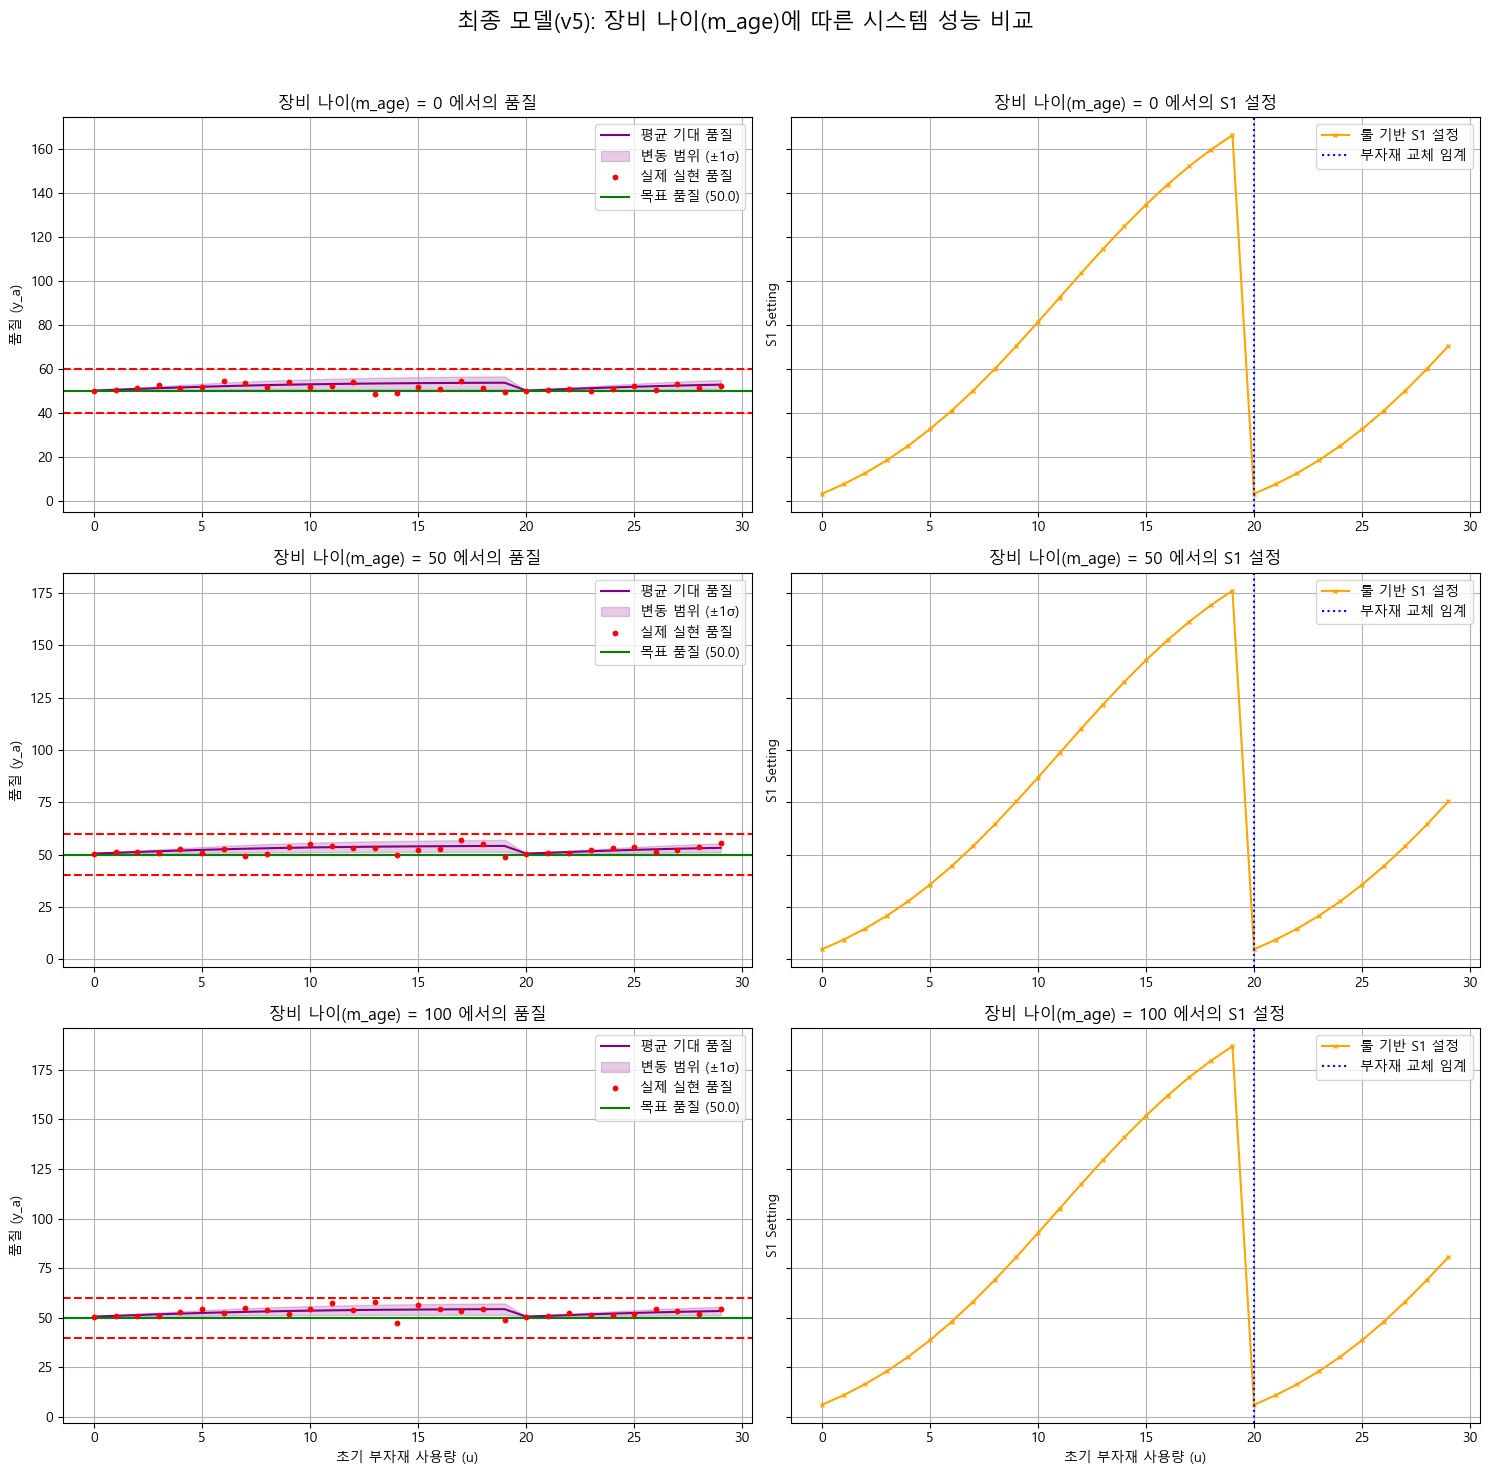

In [ ]:
machine_ages_to_test = [0, 50, 100]
consumable_usages = np.arange(0, 30, 1)

fig, axes = plt.subplots(len(machine_ages_to_test), 2, figsize=(15, 15), sharey='row')
fig.suptitle('최종 모델(v5): 장비 나이(m_age)에 따른 시스템 성능 비교', fontsize=16)

np.random.seed(42)

for i, m_age in enumerate(machine_ages_to_test):
    mean_qas_rule, std_devs_rule, s1_values_rule, realized_qas_rule = [], [], [], []

    for u in consumable_usages:
        s1_opt, s2_def, s3_def, _, u_after = rule_based_agent_v5(u, m_age, min_A_spec, max_A_spec, s2_default, s3_default, U_max_consumable)
        
        real_qa, mean_qa, std_dev = calculate_qa_model_v5(s1_opt, s2_def, s3_def, u_after, m_age)
        
        mean_qas_rule.append(mean_qa)
        std_devs_rule.append(std_dev)
        s1_values_rule.append(s1_opt)
        realized_qas_rule.append(real_qa)

    mean_qas_rule = np.array(mean_qas_rule)
    std_devs_rule = np.array(std_devs_rule)

    # --- 왼쪽 그래프: 품질 예측 ---
    ax_left = axes[i, 0]
    ax_left.plot(consumable_usages, mean_qas_rule, label='평균 기대 품질', color='purple')
    ax_left.fill_between(consumable_usages, mean_qas_rule - std_devs_rule, mean_qas_rule + std_devs_rule, color='purple', alpha=0.2, label='변동 범위 (±1σ)')
    ax_left.scatter(consumable_usages, realized_qas_rule, color='red', s=10, label='실제 실현 품질', zorder=5)
    ax_left.axhline(y=target_A_spec, color='g', linestyle='-', label=f'목표 품질 ({target_A_spec})')
    ax_left.axhline(y=min_A_spec, color='r', linestyle='--')
    ax_left.axhline(y=max_A_spec, color='r', linestyle='--')
    ax_left.set_title(f'장비 나이(m_age) = {m_age} 에서의 품질')
    ax_left.set_ylabel('품질 (y_a)')
    ax_left.grid(True)
    ax_left.set_ylim(20, 80)
    ax_left.legend()

    # --- 오른쪽 그래프: S1 레시피 설정 ---
    ax_right = axes[i, 1]
    ax_right.plot(consumable_usages, s1_values_rule, label='룰 기반 S1 설정', color='orange', marker='x', markersize=3)
    ax_right.axvline(x=U_max_consumable, color='blue', linestyle=':', label=f'부자재 교체 임계')
    ax_right.set_title(f'장비 나이(m_age) = {m_age} 에서의 S1 설정')
    ax_right.set_ylabel('S1 Setting')
    ax_right.grid(True)
    ax_right.legend()

axes[-1, 0].set_xlabel('초기 부자재 사용량 (u)')
axes[-1, 1].set_xlabel('초기 부자재 사용량 (u)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


레시피 민감도 분석을 위한 조건 설정 완료
  - 고정 부자재 사용량 (u): 15
  - 고정 장비 나이 (m_age): 50
  - 각 설정값 당 샘플 수: 200
데이터 생성 완료. 총 샘플 수: 6600


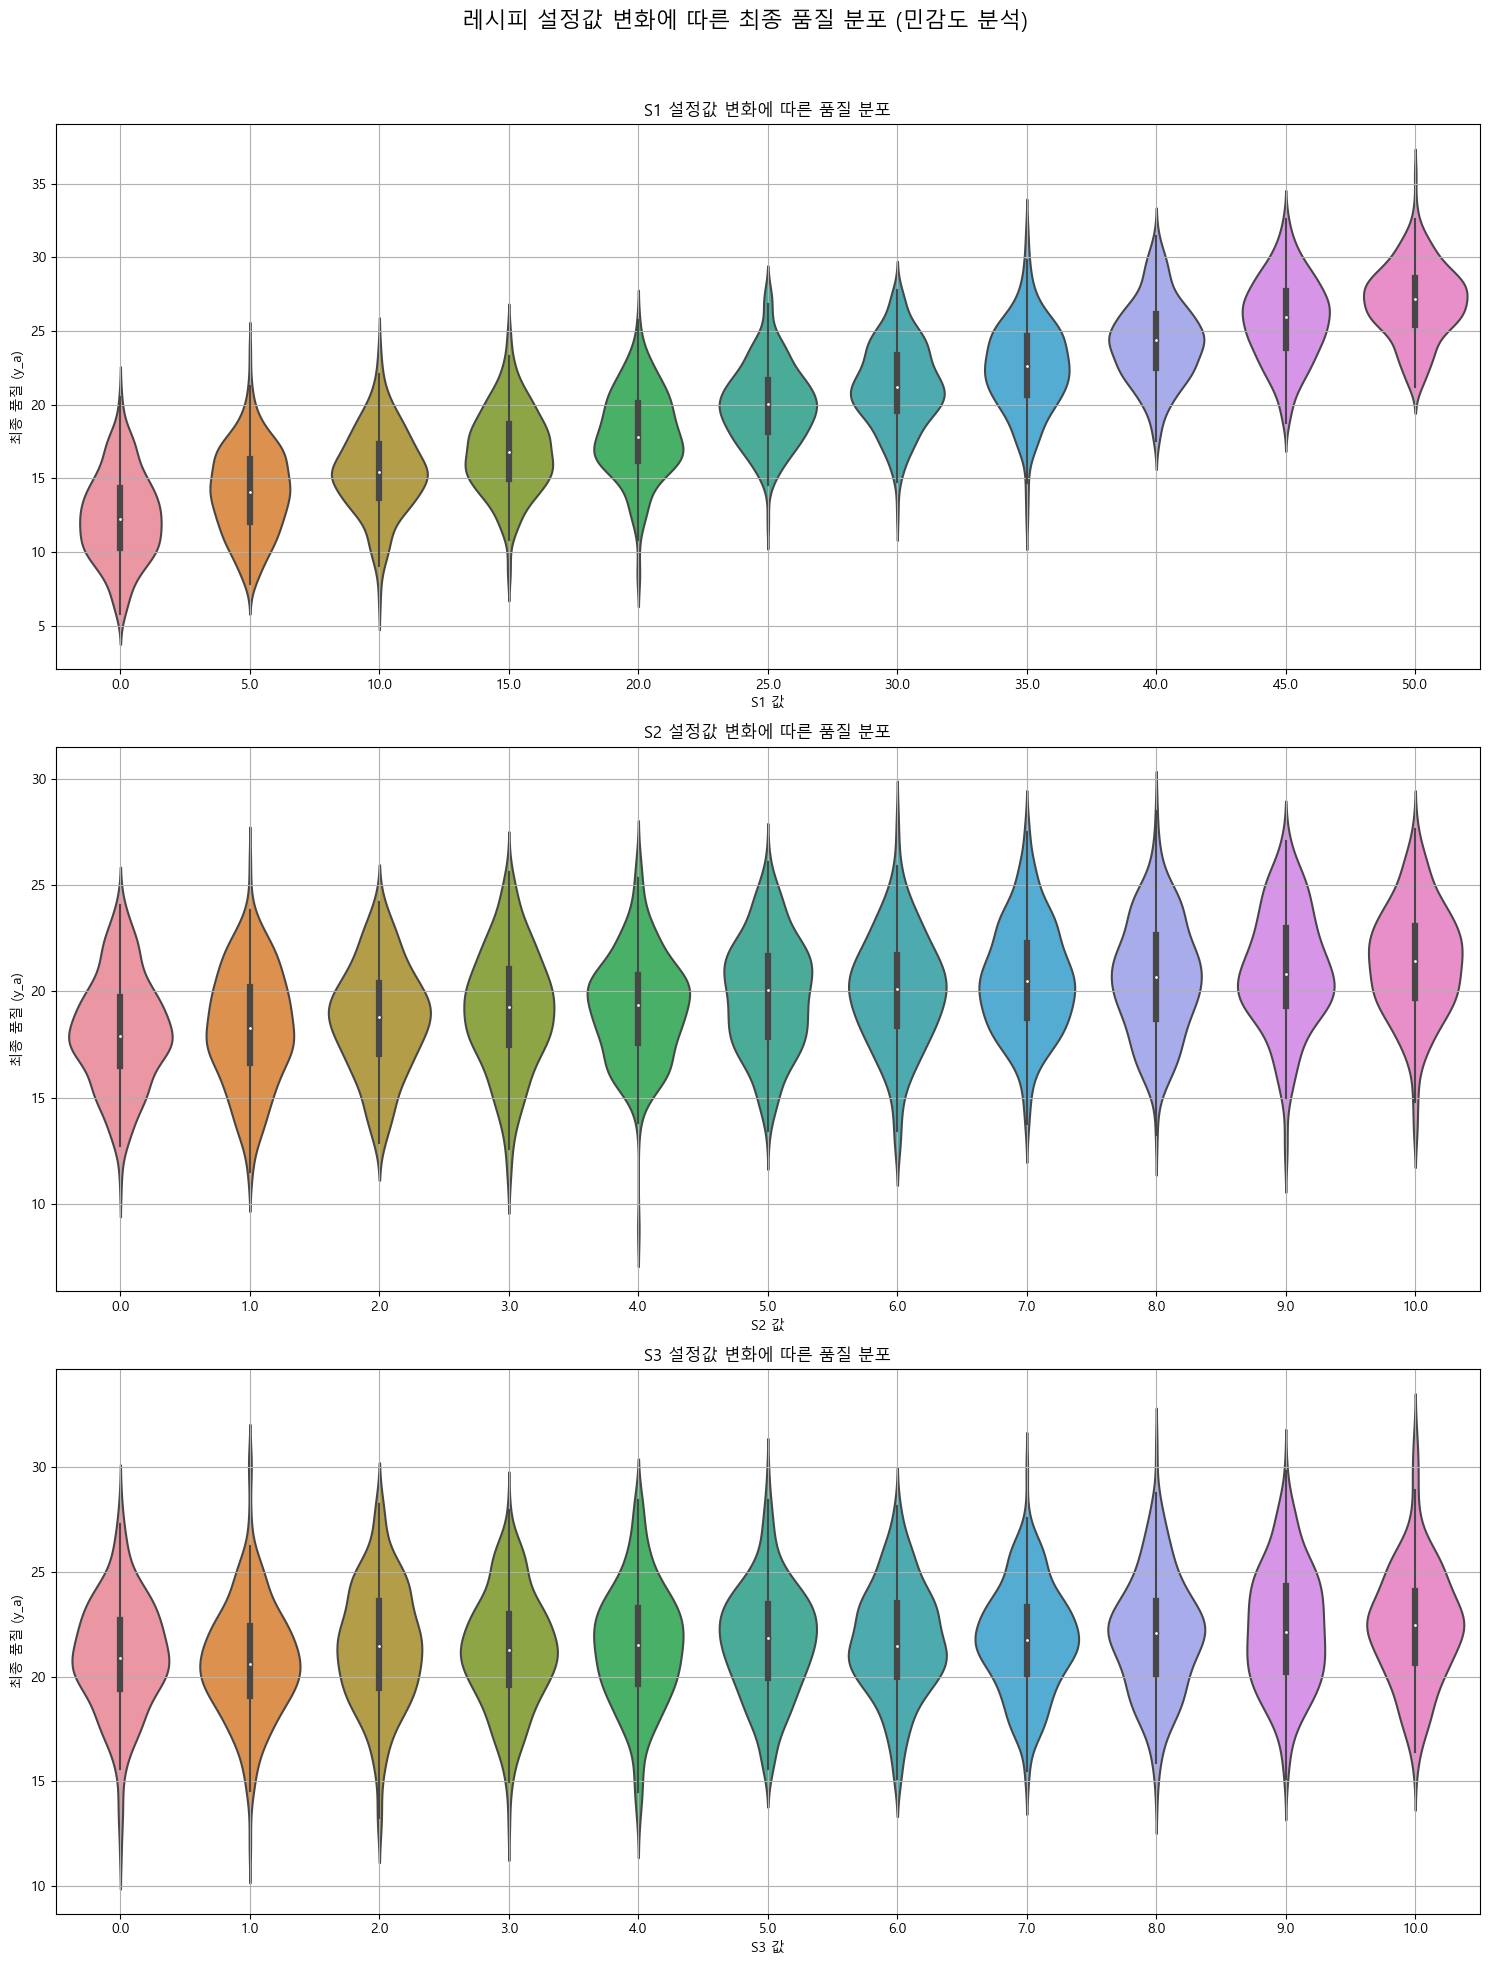

In [48]:
# --- 물리 모델 파라미터 (v5) ---
w1_base, w2_base, w3_base, b_base = 1.0, 0.8, 0.5, 40.0
w12_base = 0.02
beta, beta_k = 0.8, 0.1
gamma, gamma_k = 3.0, 0.1
delta_w1, delta_w12, delta_b = 0.001, 0.0001, 0.02

def calculate_qa_model_v5(s1, s2, s3, u, m_age):
    w1 = w1_base * (1 - delta_w1 * m_age)
    w12 = w12_base * (1 - delta_w12 * m_age)
    b = b_base - delta_b * m_age
    
    linear_part = w1 * s1 + w2_base * s2 + w3_base * s3 + b
    nonlinear_interaction = w12 * s1 * s2
    g_s = linear_part + nonlinear_interaction
    
    effectiveness = 1 - beta * np.tanh(beta_k * u)
    std_dev_noise = gamma * np.tanh(gamma_k * u)
    
    mean_qa = g_s * effectiveness
    realized_qa = np.random.normal(mean_qa, std_dev_noise)
    
    return realized_qa, mean_qa, std_dev_noise

# ===================================================================
# 시뮬레이션 조건 설정
# ===================================================================

# 각 레시피 설정(s1, s2, s3)의 탐색 범위 정의
s1_range = np.linspace(0, 50, 11)
s2_range = np.linspace(0, 10, 11)
s3_range = np.linspace(0, 10, 11)

# 다른 변수들은 중간값 또는 특정 값으로 고정
FIXED_U = 15      # 꽤 사용한 부자재
FIXED_M_AGE = 50  # 중고 장비
NUM_SAMPLES = 200 # 각 설정값에서 샘플링할 횟수

print("레시피 민감도 분석을 위한 조건 설정 완료")
print(f"  - 고정 부자재 사용량 (u): {FIXED_U}")
print(f"  - 고정 장비 나이 (m_age): {FIXED_M_AGE}")
print(f"  - 각 설정값 당 샘플 수: {NUM_SAMPLES}")

# ===================================================================
# 데이터 생성
# ===================================================================

results = []

# 1. S1 변화에 따른 품질 분포
s2_fixed, s3_fixed = np.median(s2_range), np.median(s3_range)
for s1_val in s1_range:
    for _ in range(NUM_SAMPLES):
        real_qa, _, _ = calculate_qa_model_v5(s1_val, s2_fixed, s3_fixed, FIXED_U, FIXED_M_AGE)
        results.append({'setting': 's1', 'value': s1_val, 'quality': real_qa})

# 2. S2 변화에 따른 품질 분포
s1_fixed, s3_fixed = np.median(s1_range), np.median(s3_range)
for s2_val in s2_range:
    for _ in range(NUM_SAMPLES):
        real_qa, _, _ = calculate_qa_model_v5(s1_fixed, s2_val, s3_fixed, FIXED_U, FIXED_M_AGE)
        results.append({'setting': 's2', 'value': s2_val, 'quality': real_qa})

# 3. S3 변화에 따른 품질 분포
s1_fixed, s2_fixed = np.median(s1_range), np.median(s2_range)
for s3_val in s3_range:
    for _ in range(NUM_SAMPLES):
        real_qa, _, _ = calculate_qa_model_v5(s1_fixed, s2_val, s3_val, FIXED_U, FIXED_M_AGE)
        results.append({'setting': 's3', 'value': s3_val, 'quality': real_qa})

df_sensitivity = pd.DataFrame(results)
print("데이터 생성 완료. 총 샘플 수:", len(df_sensitivity))

# ===================================================================
# 시각화: 바이올린 플롯
# ===================================================================

fig, axes = plt.subplots(3, 1, figsize=(15, 20))
fig.suptitle('레시피 설정값 변화에 따른 최종 품질 분포 (민감도 분석)', fontsize=16)

# S1 민감도 플롯
sns.violinplot(ax=axes[0], x='value', y='quality', data=df_sensitivity[df_sensitivity['setting'] == 's1'])
axes[0].set_title('S1 설정값 변화에 따른 품질 분포')
axes[0].set_xlabel('S1 값')
axes[0].set_ylabel('최종 품질 (y_a)')
axes[0].grid(True)

# S2 민감도 플롯
sns.violinplot(ax=axes[1], x='value', y='quality', data=df_sensitivity[df_sensitivity['setting'] == 's2'])
axes[1].set_title('S2 설정값 변화에 따른 품질 분포')
axes[1].set_xlabel('S2 값')
axes[1].set_ylabel('최종 품질 (y_a)')
axes[1].grid(True)

# S3 민감도 플롯
sns.violinplot(ax=axes[2], x='value', y='quality', data=df_sensitivity[df_sensitivity['setting'] == 's3'])
axes[2].set_title('S3 설정값 변화에 따른 품질 분포')
axes[2].set_xlabel('S3 값')
axes[2].set_ylabel('최종 품질 (y_a)')
axes[2].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

부자재 상태에 따른 레시피 민감도 분석 조건 설정 완료
\n데이터 생성 완료. 총 샘플 수: 7200


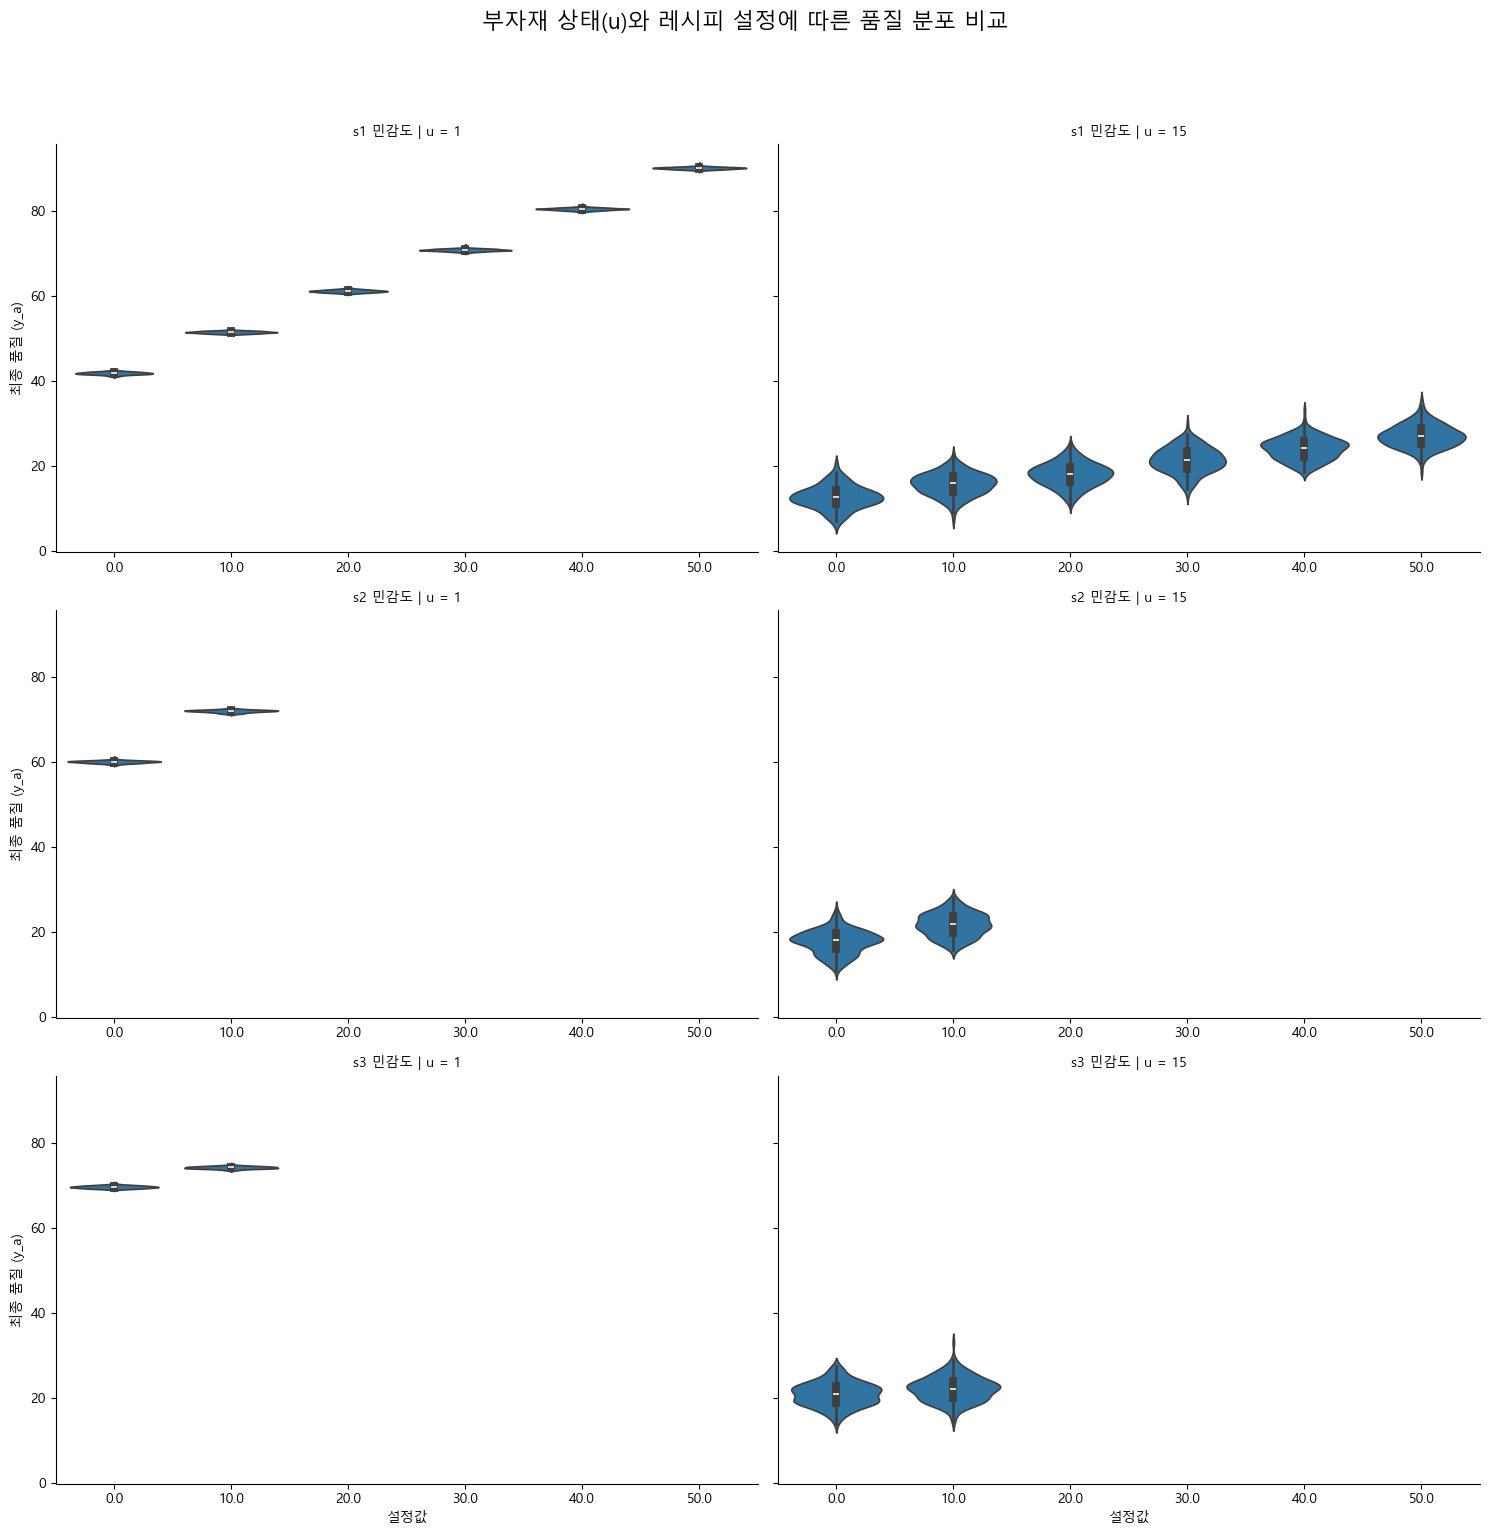

In [2]:
# --- 물리 모델 파라미터 (v5) ---
w1_base, w2_base, w3_base, b_base = 1.0, 0.8, 0.5, 40.0
w12_base = 0.02
beta, beta_k = 0.8, 0.1
gamma, gamma_k = 3.0, 0.1
delta_w1, delta_w12, delta_b = 0.001, 0.0001, 0.02

def calculate_qa_model_v5(s1, s2, s3, u, m_age):
    w1 = w1_base * (1 - delta_w1 * m_age)
    w12 = w12_base * (1 - delta_w12 * m_age)
    b = b_base - delta_b * m_age
    
    linear_part = w1 * s1 + w2_base * s2 + w3_base * s3 + b
    nonlinear_interaction = w12 * s1 * s2
    g_s = linear_part + nonlinear_interaction
    
    effectiveness = 1 - beta * np.tanh(beta_k * u)
    std_dev_noise = gamma * np.tanh(gamma_k * u)
    
    mean_qa = g_s * effectiveness
    realized_qa = np.random.normal(mean_qa, std_dev_noise)
    
    return realized_qa, mean_qa, std_dev_noise

# ===================================================================
# 시뮬레이션 조건 설정
# ===================================================================

# 각 레시피 설정(s1, s2, s3)의 탐색 범위 정의
s1_range = np.linspace(0, 50, 6) # 범위를 줄여서 시각화 속도 향상
s2_range = np.linspace(0, 10, 6)
s3_range = np.linspace(0, 10, 6)

# 비교할 부자재 사용량 시나리오
U_TO_TEST = [1, 15] # 새 부자재 vs 사용한 부자재
FIXED_M_AGE = 50
NUM_SAMPLES = 200

print("부자재 상태에 따른 레시피 민감도 분석 조건 설정 완료")

# ===================================================================
# 데이터 생성
# ===================================================================

results = []
# u 값에 대한 루프 추가
for u_scenario in U_TO_TEST:
    # S1 변화
    s2_fixed, s3_fixed = np.median(s2_range), np.median(s3_range)
    for s1_val in s1_range:
        for _ in range(NUM_SAMPLES):
            real_qa, _, _ = calculate_qa_model_v5(s1_val, s2_fixed, s3_fixed, u_scenario, FIXED_M_AGE)
            results.append({'u_state': f'u = {u_scenario}', 'setting': 's1', 'value': s1_val, 'quality': real_qa})

    # S2 변화
    s1_fixed, s3_fixed = np.median(s1_range), np.median(s3_range)
    for s2_val in s2_range:
        for _ in range(NUM_SAMPLES):
            real_qa, _, _ = calculate_qa_model_v5(s1_fixed, s2_val, s3_fixed, u_scenario, FIXED_M_AGE)
            results.append({'u_state': f'u = {u_scenario}', 'setting': 's2', 'value': s2_val, 'quality': real_qa})

    # S3 변화
    s1_fixed, s2_fixed = np.median(s1_range), np.median(s2_range)
    for s3_val in s3_range:
        for _ in range(NUM_SAMPLES):
            real_qa, _, _ = calculate_qa_model_v5(s1_fixed, s2_val, s3_val, u_scenario, FIXED_M_AGE)
            results.append({'u_state': f'u = {u_scenario}', 'setting': 's3', 'value': s3_val, 'quality': real_qa})

df_sensitivity = pd.DataFrame(results)
print("\\n데이터 생성 완료. 총 샘플 수:", len(df_sensitivity))

# ===================================================================
# 시각화: FacetGrid를 이용한 다차원 비교
# ===================================================================

# FacetGrid를 사용하여, 행(row)은 setting 변수로, 열(col)은 u_state로 나누어 그래프를 그립니다.
g = sns.FacetGrid(df_sensitivity, row="setting", col="u_state", height=5, aspect=1.5, sharey=True, sharex=False)

# 각 subplot에 violinplot을 그립니다.
g.map(sns.violinplot, "value", "quality", order=s1_range if "s1" else (s2_range if "s2" else s3_range))

g.fig.suptitle('부자재 상태(u)와 레시피 설정에 따른 품질 분포 비교', fontsize=16, y=1.02)

# 각 축의 라벨과 제목을 더 명확하게 설정
g.set_axis_labels("설정값", "최종 품질 (y_a)")
g.set_titles(row_template="{row_name} 민감도", col_template="{col_name}")

# 레이아웃 조정
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [4]:
# -*- coding: utf-8 -*-

import numpy as np
import math

# ===================================================================
# MODEL AND PARAMETERS (v5)
# ===================================================================
w1_base, w2_base, w3_base, b_base = 1.0, 0.8, 0.5, 40.0
w12_base = 0.02
beta, beta_k = 0.8, 0.1
gamma, gamma_k = 3.0, 0.1
delta_w1, delta_w12, delta_b = 0.001, 0.0001, 0.02

def calculate_mean_qa_v5(s1, s2, s3, u, m_age):
    w1 = w1_base * (1 - delta_w1 * m_age)
    w12 = w12_base * (1 - delta_w12 * m_age)
    b = b_base - delta_b * m_age
    
    linear_part = w1 * s1 + w2_base * s2 + w3_base * s3 + b
    nonlinear_interaction = w12 * s1 * s2
    g_s = linear_part + nonlinear_interaction
    
    effectiveness = 1 - beta * np.tanh(beta_k * u)
    std_dev_noise = gamma * np.tanh(gamma_k * u)
    
    mean_qa = g_s * effectiveness
    
    return mean_qa, std_dev_noise

# ===================================================================
# ANALYSIS CONDITIONS
# ===================================================================
s1_min, s1_max = 0, 50
s2_min, s2_max = 0, 10
s3_min, s3_max = 0, 10
u_min, u_max = 0, 29
FIXED_M_AGE = 50

# ===================================================================
# SCENARIO ANALYSIS
# ===================================================================
# 1. Best-Case Scenario: New consumable (u=0), MAX settings
s_max = (s1_max, s2_max, s3_max)
mean_qa_best, std_dev_best = calculate_mean_qa_v5(*s_max, u_min, FIXED_M_AGE)
quality_range_best = (mean_qa_best, mean_qa_best)

# 2. Worst-Case Scenario: Old consumable (u=29), MIN settings
s_min = (s1_min, s2_min, s3_min)
mean_qa_worst, std_dev_worst = calculate_mean_qa_v5(*s_min, u_max, FIXED_M_AGE)
quality_range_worst = (mean_qa_worst - 3 * std_dev_worst, mean_qa_worst + 3 * std_dev_worst)

# ===================================================================
# RESULTS
# ===================================================================
print("### Quality Distribution Range Analysis ###")
print(f"(Fixed machine age m_age = {FIXED_M_AGE})")
print("-" * 40)

print("\n[1] Best-Case Scenario (New Consumable u=0, Max Recipe)")
print(f"  - Mean Expected Quality: {mean_qa_best:.2f}")
print(f"  - Quality Std Dev: {std_dev_best:.2f}")
print(f"  => Predicted Quality Distribution: Approx. {quality_range_best[0]:.2f} (No noise)")

print("\n[2] Worst-Case Scenario (Old Consumable u=29, Min Recipe)")
print(f"  - Mean Expected Quality: {mean_qa_worst:.2f}")
print(f"  - Quality Std Dev: {std_dev_worst:.2f}")
print(f"  => Predicted Quality Distribution (99.7%): Approx. {quality_range_worst[0]:.2f} to {quality_range_worst[1]:.2f}")

print("-" * 40)
print(f"\nCONCLUSION: The achievable quality range in the current model is roughly between {quality_range_worst[0]:.2f} and {quality_range_best[1]:.2f}.")



### Quality Distribution Range Analysis ###
(Fixed machine age m_age = 50)
----------------------------------------

[1] Best-Case Scenario (New Consumable u=0, Max Recipe)
  - Mean Expected Quality: 109.45
  - Quality Std Dev: 0.00
  => Predicted Quality Distribution: Approx. 109.45 (No noise)

[2] Worst-Case Scenario (Old Consumable u=29, Min Recipe)
  - Mean Expected Quality: 7.99
  - Quality Std Dev: 2.98
  => Predicted Quality Distribution (99.7%): Approx. -0.96 to 16.93
----------------------------------------

CONCLUSION: The achievable quality range in the current model is roughly between -0.96 and 109.45.
